In [1]:
!pip install spex==0.1.1047 \
  -i https://test.pypi.org/simple/ \
  --extra-index-url https://pypi.org/simple/ 

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple/


In [2]:
import spex

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
/home/spex/miniconda3/envs/py311/lib/python3.11/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')
auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
import scanpy as sc
import squidpy as sq
import numpy as np
import scipy as sp

import pandas as pd
import copy

import os
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
gdat = spex.load_anndata('merfish_lung_5_reduced.h5ad')['adata']
gdat
#len(np.unique(gdat.obs.SpexCluster)) 

AnnData object with n_obs × n_vars = 28421 × 484
    obs: 'fov', 'volume', 'min_x', 'max_x', 'min_y', 'max_y'
    uns: 'spatial'
    obsm: 'blank_genes', 'spatial'

In [6]:
adata = gdat.copy()

adata = spex.preprocess(adata,do_QC=True) 

Filtering on blank genes...
Excluding bad cells and genes (singletons)...
Normalizing data...


### **Dimensionality reduction (PCA; scVI), kNN graph construction**
This function takes a pre-processed cell x gene array and performs dimensionality reduction. It then constructs a kNN graph in the reduced space and clusters this graph by optimizing the modularity. This also supports batch correction using either Harmony (from pegasus) or scVI modelling directly.

Doing dimensionality reduction...
Calculating neighborhood graph...
2025-08-02 06:17:44,693 - pegasus.tools.nearest_neighbors - INFO - in get_neighbors, K is adjusted to 136.
2025-08-02 06:17:45,898 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 1.20s.
2025-08-02 06:17:46,209 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.31s.
UMAP embedding...
2025-08-02 06:17:47,103 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2025-08-02 06:17:47,103 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[    0, 17965, 3393, ..., 3821, 4341, 17840],
       [    1, 15798, 13864, ..., 17794, 12264, 3190],
       [    2, 17990, 5666, ..., 214, 16141, 14259],
       ...,
       [18631, 8537, 12858, ..., 4270, 13731, 11988],
       [18632, 1735, 847, ..., 16496, 6722, 4799],
       [18633, 50

Epochs completed:   6%| ▌          11/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  16%| █▌         31/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  94%| █████████▎ 187/200 [00:05]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:05]

Sat Aug  2 06:17:53 2025 Finished embedding
2025-08-02 06:17:53,948 - pegasus.tools.visualization - INFO - Function 'umap' finished in 6.85s.


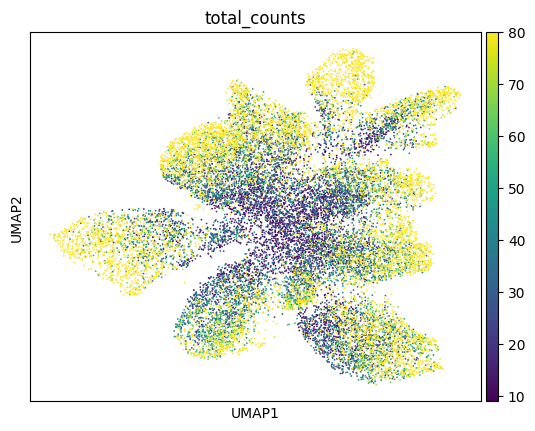

In [7]:
ddata = adata.copy()
ddata = spex.reduce_dimensionality(ddata,method='pca',prefilter=False)
sc.pl.umap(ddata,color='total_counts',vmax=80)

Doing dimensionality reduction...
Calculating neighborhood graph...
2025-08-02 06:17:55,055 - pegasus.tools.nearest_neighbors - INFO - in get_neighbors, K is adjusted to 136.
2025-08-02 06:17:56,222 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 1.17s.
2025-08-02 06:17:56,526 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.30s.
UMAP embedding...
2025-08-02 06:17:57,215 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2025-08-02 06:17:57,215 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[    0, 17965, 3393, ..., 3821, 4341, 17840],
       [    1, 15798, 13864, ..., 17794, 12264, 3190],
       [    2, 17990, 5666, ..., 214, 16141, 14259],
       ...,
       [18631, 8537, 12858, ..., 4270, 13731, 11988],
       [18632, 1735, 847, ..., 16496, 6722, 4799],
       [18633, 50

Epochs completed:   5%| ▌          10/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  16%| █▌         31/200 [00:00]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  96%| █████████▌ 191/200 [00:05]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:05]

Sat Aug  2 06:18:03 2025 Finished embedding
2025-08-02 06:18:03,137 - pegasus.tools.visualization - INFO - Function 'umap' finished in 5.92s.


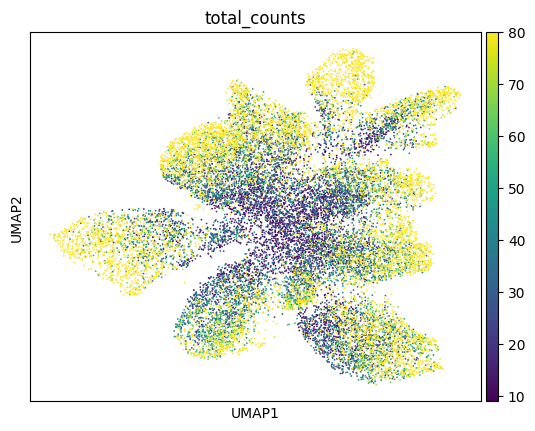

In [8]:
ddata = adata.copy()
ddata = spex.reduce_dimensionality(ddata,method='pca',prefilter=False)
sc.pl.umap(ddata,color='total_counts',vmax=80)

In [9]:
ddata.write_h5ad('HuLung_prefiltered_pegasus.h5ad')
cdata = ddata.copy()
cdata = spex.cluster(cdata,method='leiden',resolution=1.3,spatial_weight=0.0)
cdata.write_h5ad('HuLung_prefiltered_pegasus_clustered.h5ad') 

In [10]:
gclq_df, perm_test = spex.CLQ_vec_numba(cdata, clust_col='leiden', radius=50, n_perms=1000)

In [11]:
print(gclq_df)
print(perm_test)

AnnData object with n_obs × n_vars = 10 × 10
    layers: 'global_clq', 'permute_test'
AnnData object with n_obs × n_vars = 18634 × 484
    obs: 'fov', 'volume', 'min_x', 'max_x', 'min_y', 'max_y', 'blank_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'leiden'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'spatial', 'prepro', 'log1p', 'hvg', 'dim_reduce', 'pca', 'leiden', 'spatial_neighbors', 'CLQ'
    obsm: 'blank_genes', 'spatial', 'X_pca', 'neighbor_idx', 'distances', 'X_umap', 'NCV', 'local_clq'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'spatial_connectivities', 'spatial_distances'


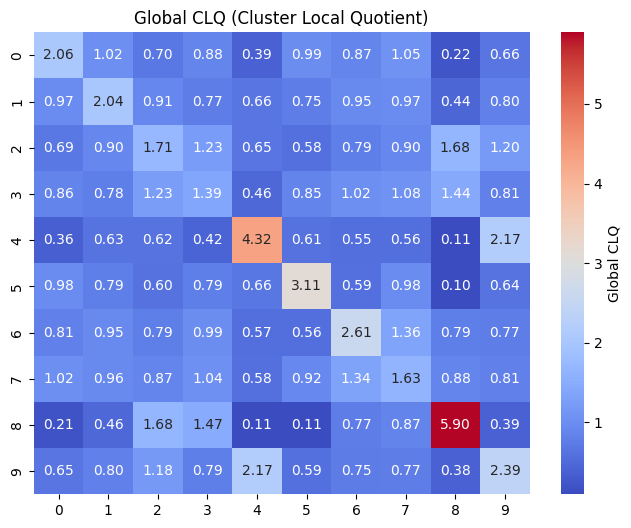

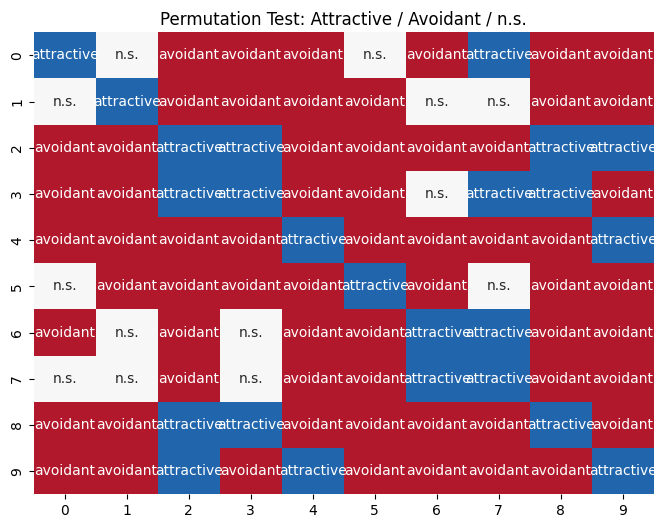

In [12]:
# Если gclq_df — это слой в AnnData
gclq_numeric = pd.DataFrame(cdata.uns['CLQ']['global_clq']).astype(float)

# --- Heatmap of Global CLQ ---
plt.figure(figsize=(8, 6))
sns.heatmap(gclq_numeric, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Global CLQ'})
plt.title("Global CLQ (Cluster Local Quotient)")
plt.show()

perm_test_df = pd.DataFrame(cdata.uns['CLQ']['permute_test'])

perm_map = perm_test_df.replace({'attractive': 1, 'n.s.': 0, 'avoidant': -1})

plt.figure(figsize=(8, 6))
sns.heatmap(perm_map, annot=perm_test_df, fmt="", cmap=sns.color_palette(["#b2182b", "#f7f7f7", "#2166ac"], as_cmap=True), cbar=False)
plt.title("Permutation Test: Attractive / Avoidant / n.s.")
plt.show()

In [13]:
def plot_joint_spatial_umap(adata, cvar='leiden', groups=None, **kwargs):
    f,a = plt.subplots(1,2)
    f.set_size_inches(10,5)

    if groups:
        sc.pl.umap(adata,color=cvar,ax=a[0],show=False,legend_loc=None,groups=groups,**kwargs)
        sq.pl.spatial_scatter(adata,color=cvar,ax=a[1],shape=None,groups=groups,**kwargs)
    else:
        sc.pl.umap(adata,color=cvar,ax=a[0],show=False,legend_loc=None,**kwargs)
        sq.pl.spatial_scatter(adata,color=cvar,ax=a[1],shape=None,**kwargs)

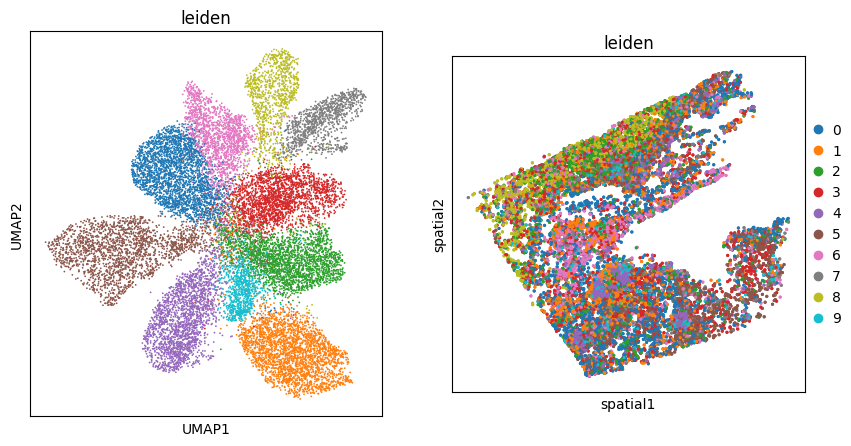

In [14]:
plot_joint_spatial_umap(cdata,cvar='leiden') 

In [15]:
import spex

cdata = sc.read_h5ad("HuLung_prefiltered_pegasus_clustered.h5ad")
cdata = spex.annotate_clusters(cdata,marker_db='human_lung,human_immune') 
cdata.write_h5ad("HuLung_prefiltered_pegasus_clustered_typed.h5ad")

2025-08-02 06:18:28,720 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 0.0565s.
calc_mwu finished for genes in [0, 484).
2025-08-02 06:18:29,014 - pegasus.tools.diff_expr - INFO - MWU test and AUROC calculation are finished. Time spent = 0.2937s.
2025-08-02 06:18:29,023 - pegasus.tools.diff_expr - INFO - Sufficient statistics are collected. Time spent = 0.0091s.
2025-08-02 06:18:29,031 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2025-08-02 06:18:29,031 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 0.37s.


### **Differentially expressed genes
There are a multitude of ways to do this. We support basic scanpy and pegasus functions, scVI functions. For more powerful/downstream analyses, diffxpy should be used (but this will be project dependent.)
TODO: add support for spatially variable genes. (SpatialDE)

In [16]:
cdata = sc.read_h5ad('HuLung_prefiltered_pegasus_clustered_typed.h5ad')
cdata.uns['log1p']['base'] = np.e

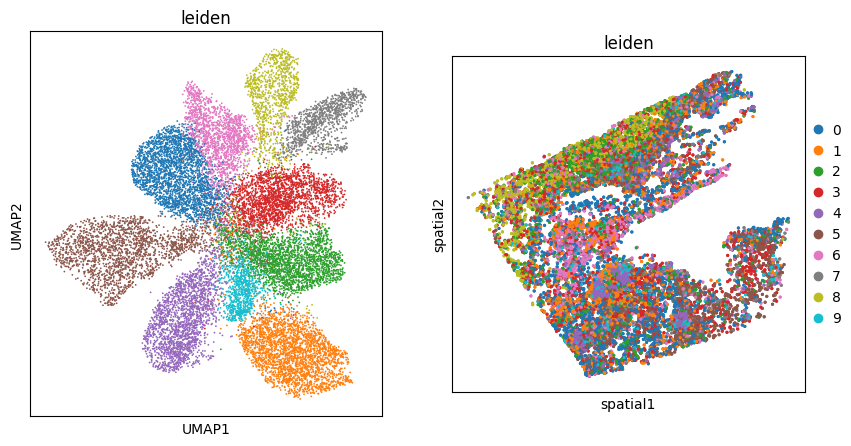

In [17]:
#plot_joint_spatial_umap(cdata,cvar='cell_type') 
plot_joint_spatial_umap(cdata, cvar='leiden')

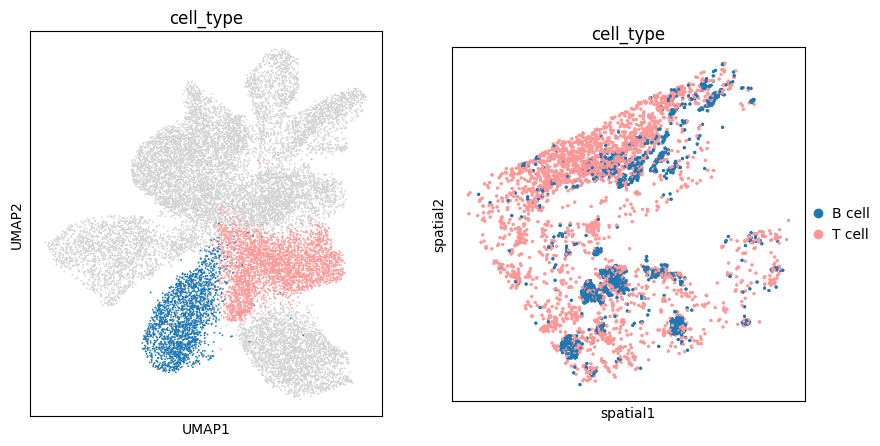

In [18]:
#cdata
plot_joint_spatial_umap(cdata,cvar='cell_type',groups=['B cell','Fibroplast','T cell']) 

In [19]:
ddata = cdata[cdata.obs.total_counts > 30,:].copy()
ddata = spex.reduce_dimensionality(ddata,mdist=0.25)

Doing dimensionality reduction...
Calculating neighborhood graph...
2025-08-02 06:18:31,598 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.72s.
2025-08-02 06:18:31,769 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.17s.
UMAP embedding...
2025-08-02 06:18:32,192 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2025-08-02 06:18:32,193 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.25, n_jobs=1, precomputed_knn=(array([[    0, 3850, 576, ..., 7481, 3632, 10309],
       [    1, 10635, 7132, ..., 4934, 11305, 9730],
       [    2, 7469, 10377, ..., 9149, 157, 1243],
       ...,
       [12570, 5752, 7254, ..., 7795, 12117, 9523],
       [12571, 3881, 1168, ..., 4256, 4295, 10436],
       [12572, 10358, 3380, ..., 12424, 8375, 9459]]), array([[0.       , 3.2706676, 3.3908255, ..., 4.1577554, 4.166303 ,
       

Epochs completed:   4%| ▎          7/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  14%| █▎         27/200 [00:00]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  94%| █████████▍ 189/200 [00:03]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:03]


Sat Aug  2 06:18:36 2025 Finished embedding
2025-08-02 06:18:36,052 - pegasus.tools.visualization - INFO - Function 'umap' finished in 3.86s.


In [20]:
cdata = sc.read_h5ad('HuLung_prefiltered_pegasus_clustered_typed.h5ad')
cdata.uns['log1p']['base'] = np.e

In [21]:
n = cdata.obs.cell_type.value_counts() 

In [22]:
cdata.obs['cell_counts'] = [x + ': ' + str(n[x]) for x in cdata.obs.cell_type] 

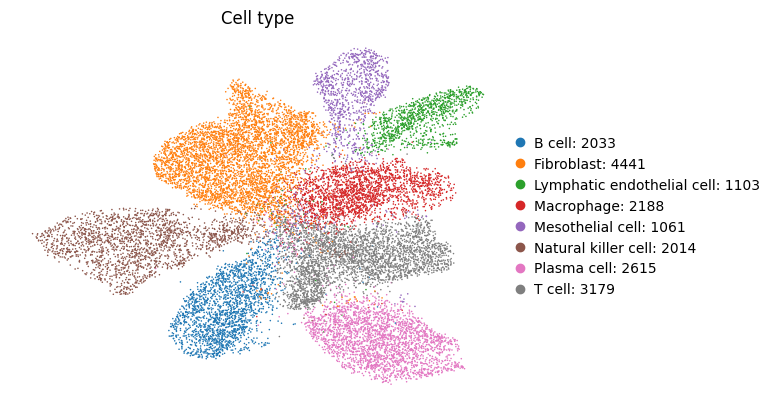

In [23]:
sc.pl.umap(cdata, color='cell_counts', frameon=False, title='Cell type', size=5, save='figA2.svg') 

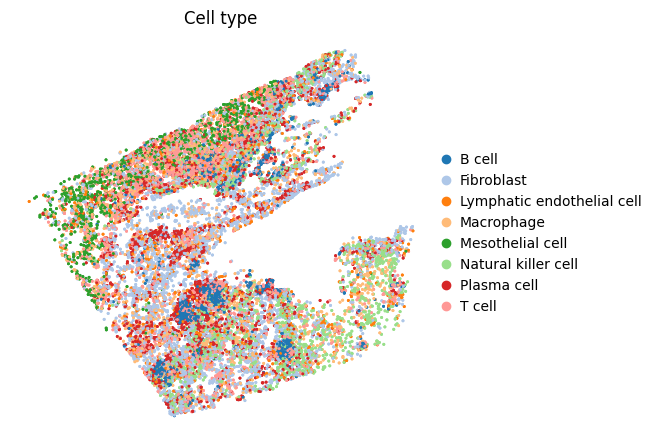

In [24]:
sq.pl.spatial_scatter(cdata, color='cell_type', frameon=False, title='Cell type', size=5, save='figB.svg',shape=None) 

In [25]:
!pip install diffxpy
!pip install NaiveDe
!pip install SpatialDE

import diffxpy.api as de
import NaiveDE
import SpatialDE

In [26]:
cdata = spex.differential_expression(cdata,method='wilcoxon') 

In [27]:
zdata = cdata.raw.to_adata().copy()
if sp.sparse.issparse(zdata.X):
    zdata.X = zdata.X.toarray()
else:
    zdata.X = np.asarray(zdata.X)
    
import diffxpy.api as de

zdata.obs['condition'] = (zdata.obs['leiden'] == '0').astype(int)
test_res = de.test.wald(
    zdata,
    factor_loc_totest='condition',
    formula_loc='~ 1 + condition',
    noise_model='nb',
    as_numeric=['condition']
)

import gc; del zdata; gc.collect()

training location model: False
training scale model: True
iter   0: ll=3468394.007554
iter   1: ll=3468394.007554, converged: 0.00% (loc: 100.00%, scale update: False), in 0.00sec
iter   2: ll=3226184.605713, converged: 0.00% (loc: 0.00%, scale update: True), in 3.46sec
iter   3: ll=3226184.605713, converged: 0.00% (loc: 100.00%, scale update: False), in 0.00sec
iter   4: ll=3221897.081916, converged: 99.38% (loc: 99.38%, scale update: True), in 3.40sec
iter   5: ll=3221897.081916, converged: 99.38% (loc: 100.00%, scale update: False), in 0.00sec
iter   6: ll=3221897.081916, converged: 100.00% (loc: 100.00%, scale update: True), in 0.30sec


8114

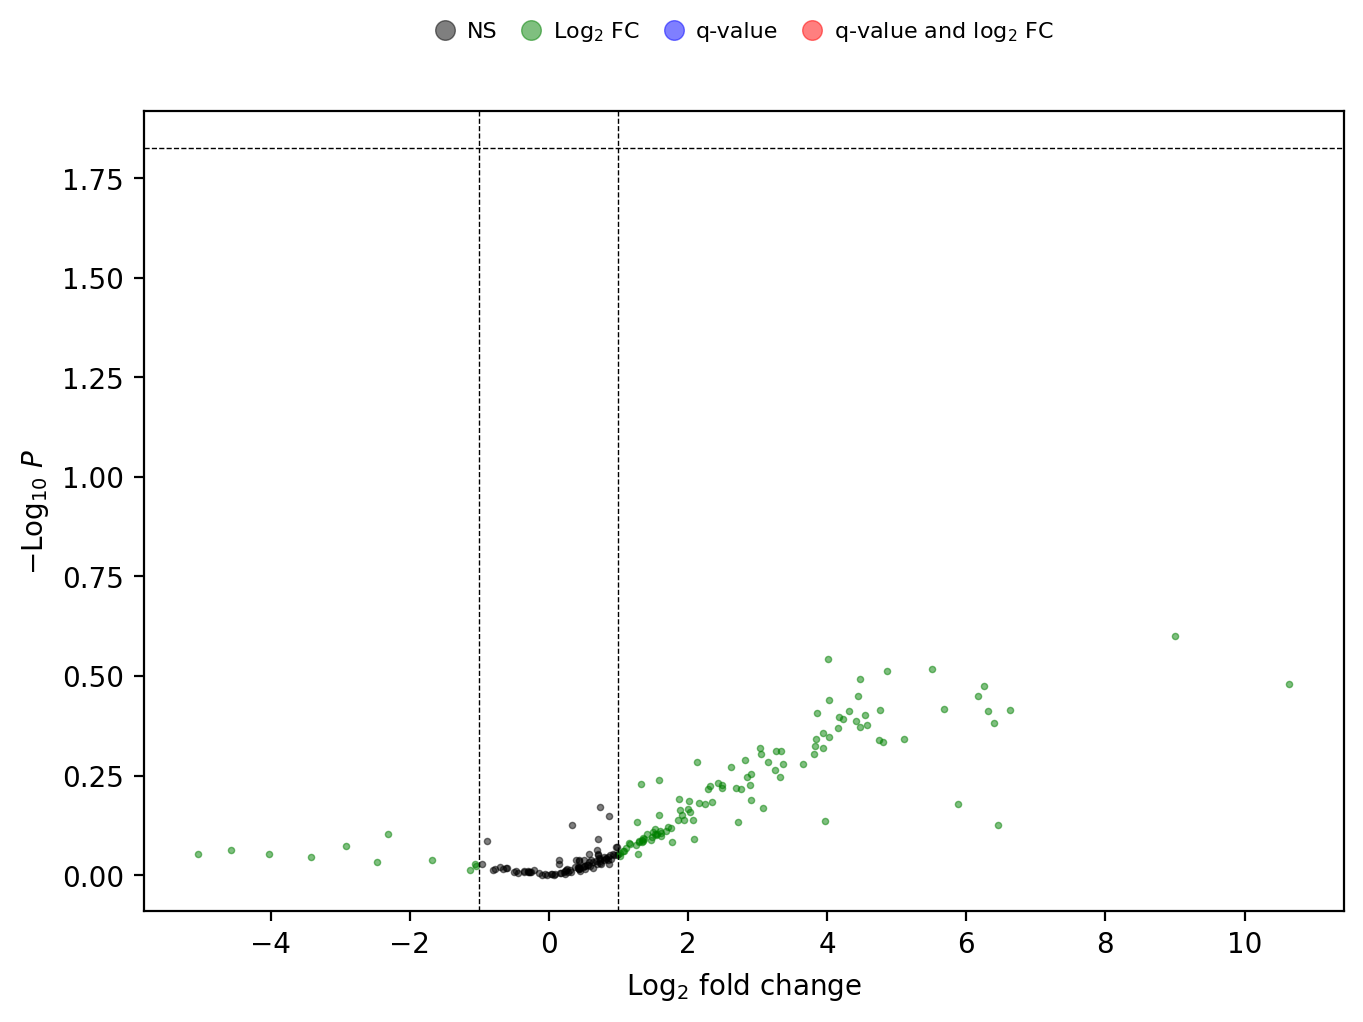

In [28]:
import pegasus as pg

pg.volcano(cdata, cluster_id = '3', dpi=200) 

categories: 0, 1, 2, etc.
var_group_labels: 8


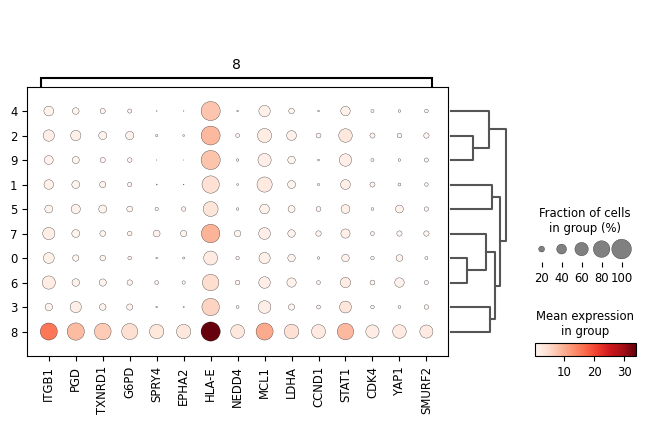

In [29]:
sc.pl.rank_genes_groups_dotplot(cdata,key='de_res',groupby='leiden',n_genes=15,groups=['8']) 

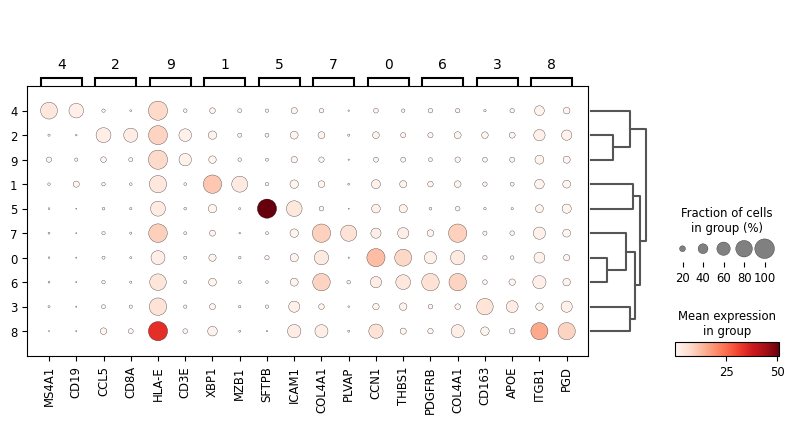

In [30]:
sc.pl.rank_genes_groups_dotplot(cdata,key='de_res',groupby='leiden',n_genes=2) 

In [31]:
#Note that running the full dataset through spatialde uses a lot of memory due to the
#Ncells x Ncells covariance matrix.
idx = cdata.obs_names[::1000]
spatial_coords = pd.DataFrame(
        {
            'x': cdata.obsm['spatial'][::1000, 0].astype(np.float64),
            'y': cdata.obsm['spatial'][::1000, 1].astype(np.float64),
        },
        index=idx,
    )
Y = cdata[idx, :].to_df()
if hasattr(Y, "sparse"):
    Y = Y.sparse.to_dense()
Y = Y.apply(pd.to_numeric, errors="coerce").astype(np.float64)
X = spatial_coords[['x','y']].to_numpy(dtype=np.float64)
m = np.isfinite(X).all(1) & np.isfinite(Y.sum(axis=1).to_numpy())

import SpatialDE.util as sdu
sdu.sp = np

res = SpatialDE.run(X[m], Y.iloc[m, :])

Models: 100%|██████████| 10/10 [00:06<00:00,  1.53it/s]


###Cluster annotation - cell typing and pathway analysis
This function takes a cluster of cells and sets of marker genes/gene weights and calculates how well each cluster matches with each set. These sets can be cell types, pathways, etc. Also supports label transfer.

In [32]:
import decoupler as dc
cdata = spex.annotate_clusters(cdata,marker_db='human_lung,human_immune') 

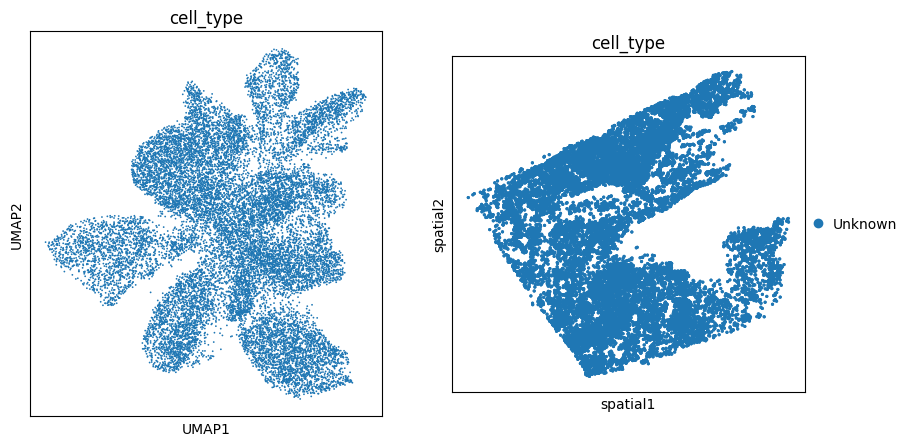

In [33]:
cdata
adata
cdata.obs['cell_type'] = cdata.obs['cell_type'].astype('category')
cdata.obs['cell_type'] = cdata.obs['cell_type'].cat.remove_unused_categories()
if 'cell_type_colors' in cdata.uns:
    cats = list(cdata.obs['cell_type'].cat.categories)
    cdata.uns['cell_type_colors'] = cdata.uns['cell_type_colors'][:len(cats)]
plot_joint_spatial_umap(cdata,cvar='cell_type') 

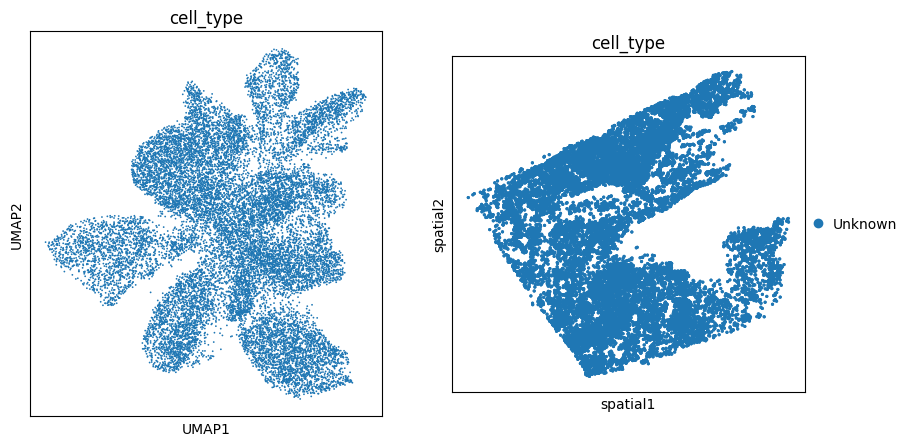

In [34]:
cdata.obs["cell_type"].unique().tolist()


plot_joint_spatial_umap(cdata,cvar='cell_type',groups=['Unknown']) 

In [35]:
ddata = cdata[cdata.obs.total_counts > 30,:].copy()
ddata = spex.reduce_dimensionality(ddata,mdist=0.25)

Doing dimensionality reduction...
Calculating neighborhood graph...
2025-08-02 06:18:58,754 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.72s.
2025-08-02 06:18:58,917 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.16s.
UMAP embedding...
2025-08-02 06:18:59,340 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2025-08-02 06:18:59,341 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.25, n_jobs=1, precomputed_knn=(array([[    0, 3850, 576, ..., 7481, 3632, 10309],
       [    1, 10635, 7132, ..., 4934, 11305, 9730],
       [    2, 7469, 10377, ..., 9149, 157, 1243],
       ...,
       [12570, 5752, 7254, ..., 7795, 12117, 9523],
       [12571, 3881, 1168, ..., 4256, 4295, 10436],
       [12572, 10358, 3380, ..., 12424, 8375, 9459]]), array([[0.       , 3.2706676, 3.3908255, ..., 4.1577554, 4.166303 ,
       

Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  14%| █▍         28/200 [00:00]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  95%| █████████▌ 190/200 [00:03]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:03]

Sat Aug  2 06:19:03 2025 Finished embedding
2025-08-02 06:19:03,151 - pegasus.tools.visualization - INFO - Function 'umap' finished in 3.81s.


In [36]:
#cdata

ddata
ddata = spex.annotate_clusters(ddata)

for cid in ddata.uns['cell_typing']:
     ddata.uns['cell_typing'][cid] = [str(x) for x in ddata.uns['cell_typing'][cid]]
ddata.write_h5ad('HuLung_prefiltered_pegasus_clustered_typed.h5ad')

In [37]:
cdata = spex.analyze_pathways(cdata)

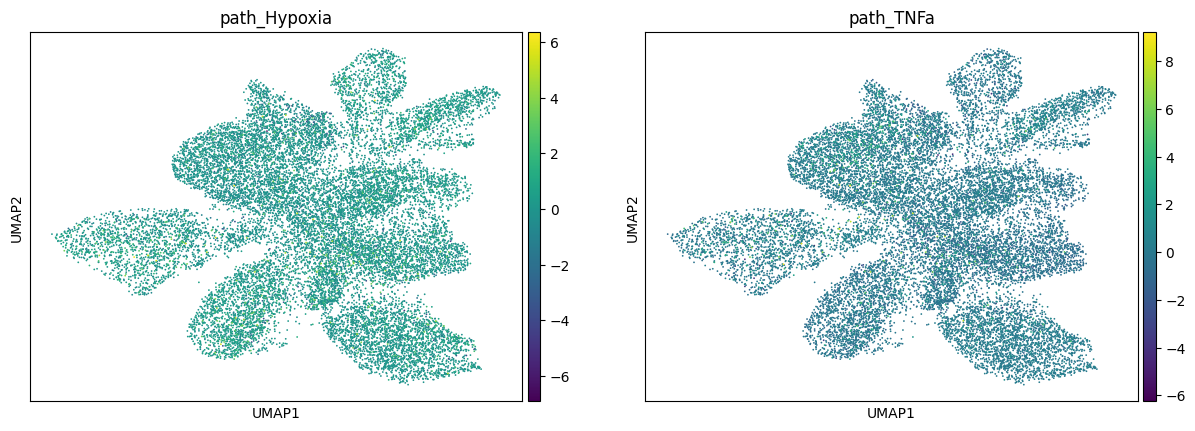

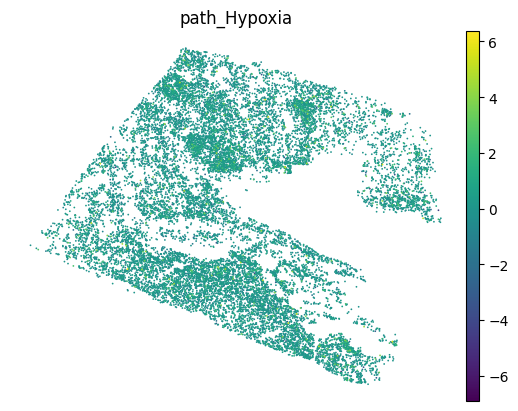

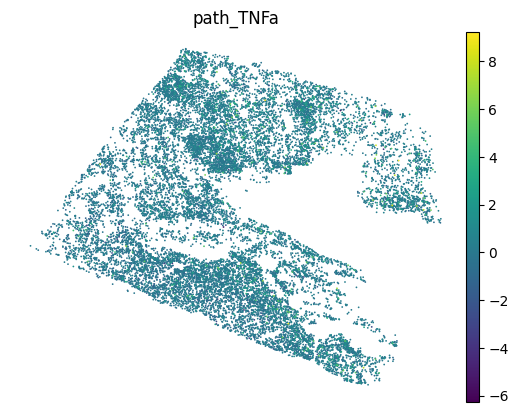

In [38]:
import scanpy as sc
import squidpy as sq

# pick pathways to show
paths = ["Hypoxia", "TNFa"]  # change as needed
for p in paths:
    cdata.obs[f"path_{p}"] = cdata.obsm["pathway_scores"][p].astype(float)

# UMAP
sc.pl.umap(cdata, color=[f"path_{p}" for p in paths], cmap="viridis")

# Spatial
for p in paths:
    sc.pl.embedding(cdata, basis="spatial", color=f"path_{p}", cmap="viridis", frameon=False)

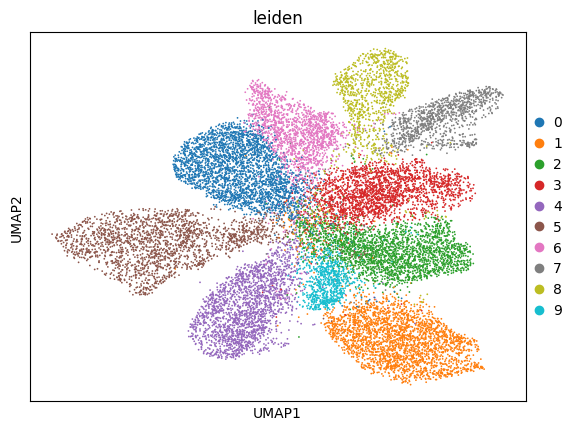

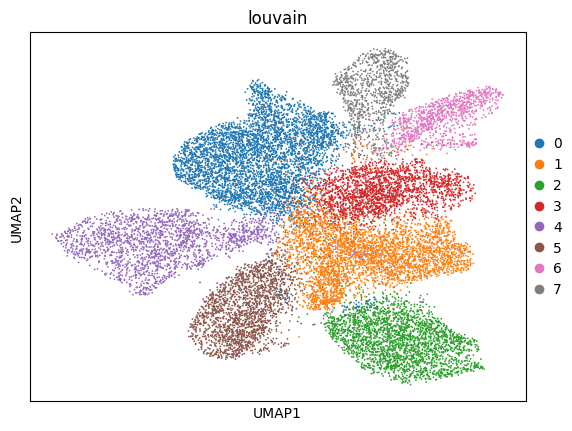

In [39]:
# import scanpy as sc
# if 'connectivities' not in cdata.obsp:
#     sc.pp.neighbors(cdata, use_rep='X_pca' if 'X_pca' in cdata.obsm else None, n_neighbors=15)
ldata = spex.niche(cdata.copy(), spatial_weight=0.5, resolution=1, method='leiden')  # or method='louvain'    
ldata.obs['leiden'].value_counts()
sc.pl.umap(ldata, color='leiden')

cdata = spex.niche(cdata, spatial_weight=0.5, resolution=0.6, method='louvain')  # or method='louvain'    
cdata.obs['louvain'].value_counts()
sc.pl.umap(cdata, color='louvain')

In [40]:
cdata.obsm['spatial'] 

array([[1975.97766218, 3227.17280924],
       [3404.4159937 , 3673.58013707],
       [3603.53005937, 5529.2833319 ],
       ...,
       [6709.68043292, 5573.24702816],
       [3764.17688188, 2361.03436221],
       [4389.53484941, 2105.87046263]])

In [41]:
cdata

AnnData object with n_obs × n_vars = 18634 × 484
    obs: 'fov', 'volume', 'min_x', 'max_x', 'min_y', 'max_y', 'blank_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'leiden', 'cell_type', 'cell_counts', 'path_Hypoxia', 'path_TNFa', 'louvain'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'cell_typing', 'dim_reduce', 'hvg', 'leiden', 'log1p', 'pca', 'prepro', 'spatial', 'cell_counts_colors', 'de_res', 'dendrogram_leiden', 'louvain', 'louvain_colors'
    obsm: 'X_pca', 'X_umap', 'blank_genes', 'distances', 'neighbor_idx', 'score_mlm', 'spatial', 'padj_mlm', 'pathway_scores'
    varm: 'PCs', 'de_res'
    layers: 'counts'
    obsp: 'connectivities'